<a href="https://colab.research.google.com/github/alejomomoreno-gif/telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")#completa el código
usage = pd.read_csv("/datasets/usage.csv")#completa el código

In [ ]:
plans.head(5)# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head(5)# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head(5)# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
print(usage.isna().sum())# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

Dataset users:

churn_date: 3.534 nulos (88.35%). No representa un error, sino que la gran mayoría de clientes siguen activos (solo 11.6% canceló el servicio). Por ende, los ignoraría y los mantendría

city: 469 nulos (11.73%). Falta la ciudad de residencia en un porcentaje moderado de usuarios. Lo mantendría como nulo o los pondría en una categoría "desconocida"


Dataset usage:

duration: 22.076 nulos (55.19%). Faltante estructural ligado a eventos de texto.
length: 17.896 nulos (44.74%). Faltante estructural ligado a llamadas de voz.
Mantendría los nulos de estas dos categorías ya que corresponden a un MAR

date: 50 nulos (0.13%). Registros aislados con fecha no registrada o corrupta. Ignorar o excluir, ya que representan un porcentaje muy bajo de los datos, por lo que no afecta en gran proporción el análisis.

Resto de columnas (id, user_id, type): 0% nulos.
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
print(users[["age","user_id"]].describe())# explorar columnas numéricas de users

               age       user_id
count  4000.000000   4000.000000
mean     33.739750  11999.500000
std     123.232257   1154.844867
min    -999.000000  10000.000000
25%      32.000000  10999.750000
50%      47.000000  11999.500000
75%      63.000000  12999.250000
max      79.000000  13999.000000


- La columna `user_id` parece totalmente perfecta. Ya que count detecta 4000 usuarios y el mínimo y el máximo convergen en el rango esperado de 10000 a 14000, el cual mide 4000 usuarios (de 10,000 hasta 14,000), se puede decir que es probable que esta columna o necesite cambios
- La columna `age` contiene un outlier que afecta las mediciones estadísticas utilizadas. Es el min(-999) el cual es un dato erróneo que se debe eliminar del data set o ser remplazado por la mediana

In [ ]:
print(usage[["id","user_id"]].describe())# explorar columnas numéricas de usage

                id       user_id
count  40000.00000  40000.000000
mean   20000.50000  12002.405975
std    11547.14972   1157.279564
min        1.00000  10000.000000
25%    10000.75000  10996.000000
50%    20000.50000  12013.000000
75%    30000.25000  13005.000000
max    40000.00000  13999.000000


- Las columnas `id` corresponde al identificador único de cada registro de actividad. Presenta una secuencia regular que va del 1 al 40,000 sin valores nulos ni anómalos. User_id representa la clave de enlace con la tabla users. Su rango coincide exactamente con el catálogo de clientes (mínimo 10,000 y máximo 13,999), lo que confirma integridad referencial entre ambas tablas sin identificadores fuera de los límites esperados.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` faltan datos, deberían ser 4000 counts y solo hay 3531. La alta frecuencia de Bogotá es totalmente normal, dado que solo hay 6 ciudades en el dataset. De igual manera, esto puede cambiar con los datos faltantes.
- La columna `plan` esta bien construida. No hay errores en los registros, unique concuerda con los únicos dos tipos de planes, counts concuerda con el valor esperado 4000. Se puede decir que se resumen estadístico es positivo

In [ ]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` está completa con 40,000 registros y no presenta valores nulos. Contiene exactamente 2 categorías únicas (text y call)

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.
age (users) contiene el valor sentinel -999, el cual es una edad biológicamente imposible y sesga fuertemente el cálculo de la media y la desviación estándar.
city (users) contiene el caracter '?' como marcador de posición para datos no registrados o desconocidos.
Solución
Para age, reemplazar el valor -999 por la mediana de las edades válidas (47 años) para no alterar la distribución de los usuarios reales.
Para city, sustituir el caracter '?' por un valor nulo estándar (pd.NA / np.nan), permitiendo tratarlo explícitamente como dato faltante sin distorsionar el conteo de categorías.
Para el resto de datos:
Parecen estar bien registrados y convergen con los valores esperados en el resumen estadístico

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] =pd.to_datetime(users['reg_date'],errors="coerce") # completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"],errors="coerce")# completa el código

In [ ]:
print(users["reg_date"].describe())# Revisar los años presentes en `reg_date` de users


count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object


En `reg_date`, el año máximo no concuerda con lo que se cubre en el análisis (hasta 2024). El valor más repetido indica que 40 usuarios tienen la misma fecha a la media noche lo cual es improbable.

In [ ]:
print(usage["date"].describe())# Revisar los años presentes en `date` de usage


count                             39950
unique                            39950
top       2024-06-16 13:26:59.770494262
freq                                  1
first               2024-01-01 00:00:00
last                2024-06-30 00:00:00
Name: date, dtype: object


En `date`, en esta columna la frecuencia mayor concuerda con lo esperado (un valor bajo). Faltan 50 registros, los cuales fueron reemplazados por nulos que en gran escala no afectan el análisis.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: El único dataframe que presenta datos que no han transcurrido en el momento de guardar los datos. Yo los caparía o haría una copia del dataset y eliminaría los datos no válidos.


**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", np.nan)
users["city"].describe()

# Verificar cambios


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:

# Marcar fechas futuras como NA para reg_date


users.loc[users["reg_date"] > "2023-12-31","reg_date"] = pd.NaT
users["reg_date"].describe()


# Verificar cambios



count                              2627
unique                             2627
top       2022-05-29 22:58:25.476369092
freq                                  1
first               2022-01-01 00:00:00
last      2023-12-30 21:42:48.342085528
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby("type")["duration"].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby("type")["length"].apply(lambda x: x.isna().sum())

type
call    17896
text        0
Name: length, dtype: int64

los missing de durarion son correlacionados con text lo cual tiene sentido porque son mensajes, los de length con call lo que concuerda con lo esperado ya que duración (legth) solo se puede medir en las llamadas

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text","is_call","duration"]].apply(lambda x: x.sum()).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7.0,3.0,23.70
1,10001,5.0,10.0,33.18
2,10002,5.0,2.0,10.74


In [ ]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7.0,3.0,23.70
1,10001,5.0,10.0,33.18
2,10002,5.0,2.0,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg,on="user_id",how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[["cant_mensajes","cant_llamadas","cant_minutos_llamada"]].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [ ]:
user_profile["plan"].value_counts(normalize=True)# Distribución porcentual del tipo de plan


Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

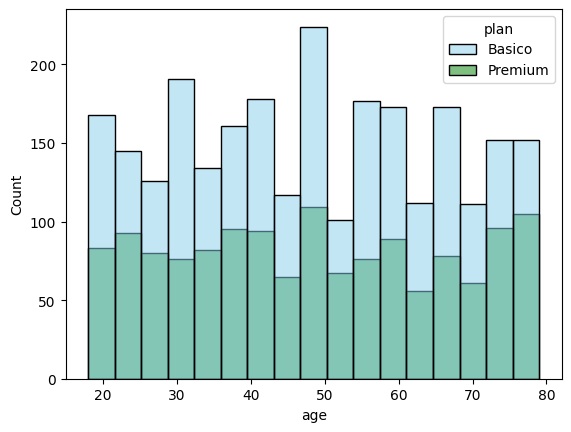

In [ ]:
# Histograma para visualizar la edad (age)

sns.histplot(x=user_profile["age"], hue=user_profile["plan"], palette=["skyblue","green"])
plt.show()


💡Insights:
- La mayoría de los usuarios tienen cerca de 50 años. Sin embargo, hay una distribución muy uniforme, ya que, como se observa en el gráfica entre edades bajas (cerca de 20 años) al igual que en las altas (cerca de los 80) la frecuencia por edad es similar: El patrón no es afectado por el tipo de plan a grandes rasgos.

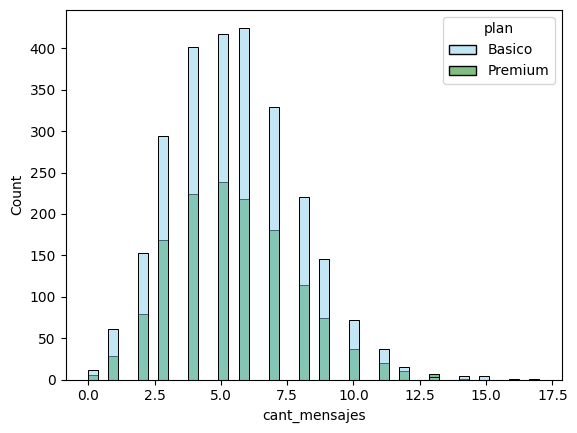

In [ ]:
# Histograma para visualizar la cant_mensajes

sns.histplot(x=user_profile["cant_mensajes"], hue=user_profile["plan"], palette=["skyblue","green"])
plt.show()



💡Insights:
- Tiene una distribución sesgada a la derecha. La mayoría de las cant_mensajes se concentran entre 0 y 12.5 mensajes. No se denota un patrón claro entre los tipos de planes.

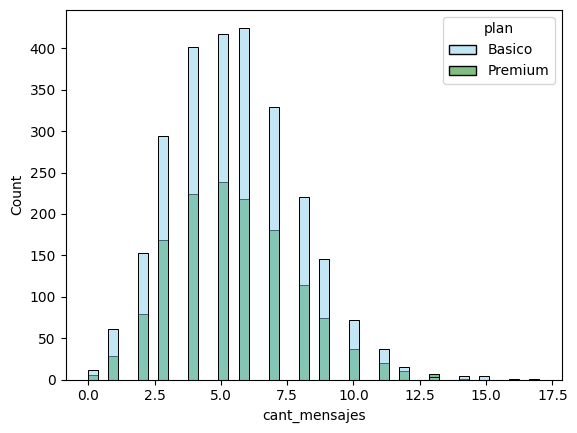

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(x=user_profile["cant_mensajes"], hue=user_profile["plan"], palette=["skyblue","green"])
plt.show()




💡Insights:
- La gráfica muestra un sesgo hacia la derecha. La proporción entre basico y `premium no muestra un patrón claro, considerando que la proporción entre los dos tipos de planes es amplia. Lo que hace que el plan básico siempre este por encima del premium

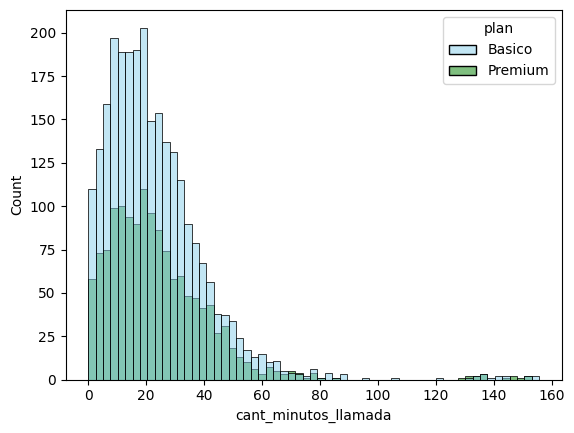

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(x=user_profile["cant_minutos_llamada"], hue=user_profile["plan"], palette=["skyblue","green"])
plt.show()


💡Insights:
- Hay una alta concentración de minutos de llamada en un rango de 0 a 90 minutos aprox. Hay un sesgo a la derecha con datos atípicos, pero razonables ya que una llamada puede durar perfectamente 2-3 horas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

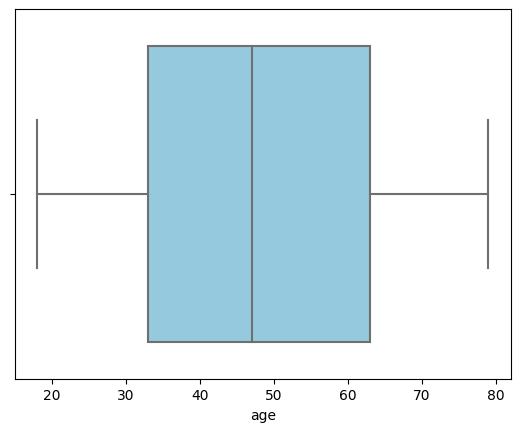

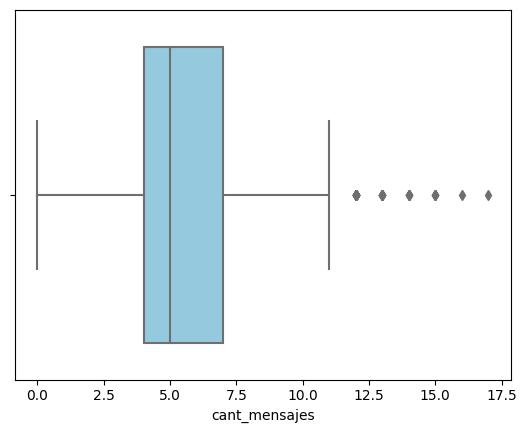

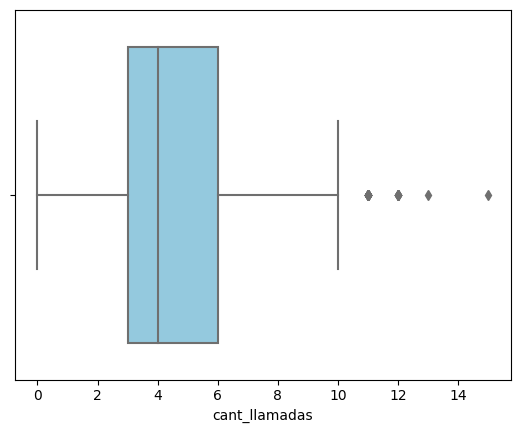

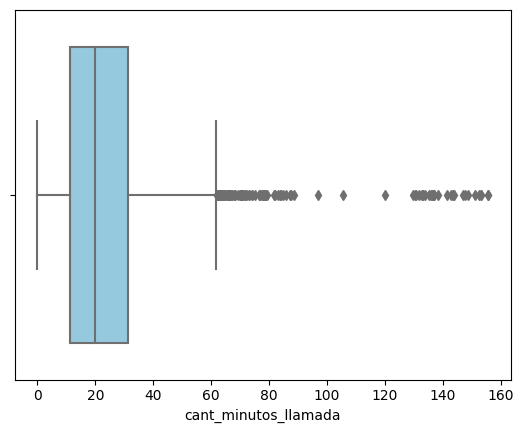

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color="skyblue")
    plt.show()




💡Insights:
- Age: No
- cant_mensajes: Si
- cant_llamadas: Si
- cant_minutos_llamada: Si

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for cols in columnas_limites:
    q1=user_profile[cols].quantile(0.25)
    q3=user_profile[cols].quantile(0.75)
    iqr=q3-q1
    l_s=q3+1.5*iqr
    l_i=q1-1.5*iqr
    print(f"limites superiores:´{cols}: {l_s}")
    print(f"limites inferiores:´{cols}: {l_i}")



limites superiores:´age: 108.0
limites inferiores:´age: -12.0
limites superiores:´cant_mensajes: 11.5
limites inferiores:´cant_mensajes: -0.5
limites superiores:´cant_llamadas: 10.5
limites inferiores:´cant_llamadas: -1.5
limites superiores:´cant_minutos_llamada: 61.8575
limites inferiores:´cant_minutos_llamada: -19.322500000000005


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()



,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: Mantener porque son un resultado totalmente plausible
- cant_llamadas: Mantener porque también es un resultado plausible
- cant_minutos_llamada: Mantener porque son resultados plausibles

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificacion(row):
    if row["cant_llamadas"]<5 and row["cant_mensajes"]<5:
        return "bajo uso"
    elif row["cant_llamadas"]<10 and row["cant_mensajes"]<10:
        return "uso medio"
    else:
        return "alto uso"
user_profile["grupo_uso"]=user_profile.apply(clasificacion,axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def edad(row):
    if row["age"]<30:
        return "joven"
    elif row["age"]<60:
        return "adulto"
    else:
        return "adulto mayor"
user_profile["grupo_edad"]=user_profile.apply(edad,axis=1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,uso medio,adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,alto uso,adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,uso medio,adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,alto uso,adulto mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,bajo uso,adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

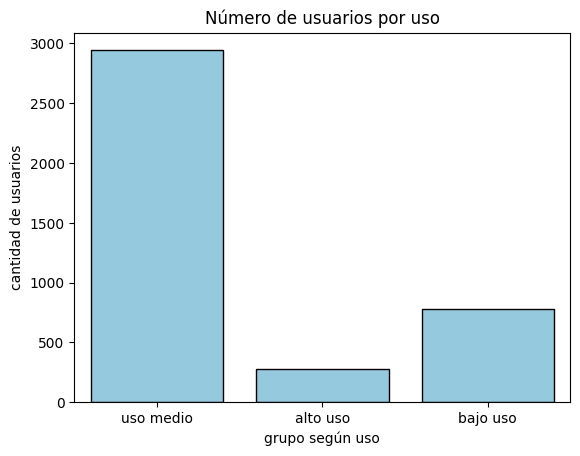

uso medio    0.73575
bajo uso     0.19450
alto uso     0.06975
Name: grupo_uso, dtype: float64


In [ ]:
# Visualización de los segmentos por uso
sns.countplot(x=user_profile["grupo_uso"], color="skyblue",edgecolor="black")
plt.xlabel("grupo según uso")
plt.ylabel("cantidad de usuarios")
plt.title("Número de usuarios por uso")
plt.show()
print(user_profile["grupo_uso"].value_counts(normalize=True))

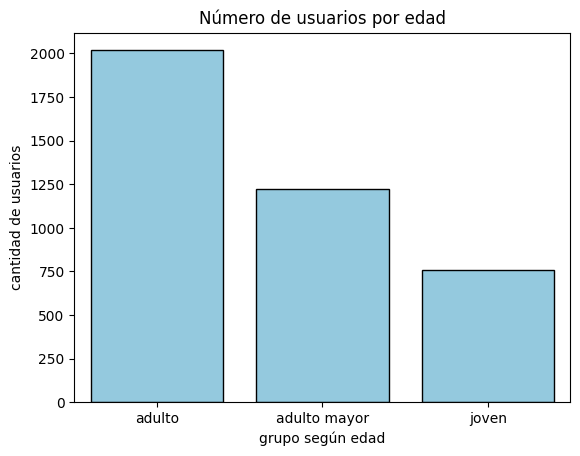

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(x=user_profile["grupo_edad"], color="skyblue",edgecolor="black")
plt.xlabel("grupo según edad")
plt.ylabel("cantidad de usuarios")
plt.title("Número de usuarios por edad")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores nulos:
  - `churn_date` en `users`: 3.534 nulos (88.35%), correspondientes a clientes activos.
  - `city` en `users`: 469 nulos (11.73%), sin ciudad de registro.
  - `duration` y `length` en `usage`: 22.076 nulos (55.19%) y 17.896 nulos (44.74%) respectivamente, producto de ausencias MAR según el servicio (`text` vs. `call`).
  - `date` en `usage`: 50 nulos (0.13%).
- Valores inválidos y sentinels:
  - `age` en `users`: Presencia del sentinel `-999`, imputado con la mediana (47 años).
  - `city` en `users`: 96 registros con `?` sustituidos por nulos.
  - `reg_date` en `users`: 1.373 registros con fechas futuras posteriores a 2023 marcadas como `NaT`.

🔍 **Segmentos por Edad**
- Se observa que la mayoría de los usuarios son mayores de 30 años cubriendo más del 80% total
📊 **Segmentos por Nivel de Uso**
- La mayoría de usuarios se concentra en el cohorte uso medio, cubriendo más del 70% total. También se destaca un bajo grupo de usuarios con alto uso (tan solo llegan al 7% total aprox.)


➡️ Esto sugiere que la mayoría de usuarios se concentran en uso medio y son adultos mayores de 30 años.

💡 **Recomendaciones**
- Crear un plan intermedio entre el plan básico y premium. Al implementar este nuevo plan, es probable que un gran segmento de usuarios que se encuentran en el plan básico, que pertenecen al grupo de uso medio y alto quieran adquirir la nueva oferta. Lo cual incrementaría el beneficio de la empresa, ya que capturaría un grupo que no cree que pagar el plan premium valga la pena pero que su plan actual no los satisface completamente.
- Para incrementar los usuarios jóvenes de la compañía, se recomiendan campañas publicitarias. También para tener una mayor presencia en este grupo se deberían utilizar los medios de comunicación en tendencia, como plataformas de streaming, por ejemplo: kick, tiktok (entre otros). Asimismo, se deberían efectuar estas campañas de la mano de figuras públicas con alto impacto en la región y en estas plataformas.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`